In [1]:
import os
from io import BytesIO
import requests
from datetime import datetime,timedelta
import warnings
import xarray as xr
import io
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap
import pandas as pd
import matplotlib.patheffects as path_effects
from matplotlib.colors import ListedColormap
from matplotlib.colorbar import ColorbarBase
import matplotlib.colors as mcolors
import helper_dicts as hdict
import helper_functions as helper
%load_ext autoreload
%autoreload 2
import cftime
import dask
import rioxarray
from dateutil.relativedelta import relativedelta
import cfgrib

In [2]:
stations = [{'name': 'Chuuk-Weno_FSM','lat': 7.45, 'lon': 151.85 },
            { 'name': 'Colonia-Yap_FSM', 'lat': 9.52, 'lon': 138.13 },
            { 'name': 'Lukunor_FSM', 'lat': 5.502, 'lon': 153.817 },
            { 'name': 'Kolonia-Pohnpei_FSM', 'lat': 6.984, 'lon': 158.207 },
            { 'name': 'Kosrae_FSM', 'lat': 5.326, 'lon': 163.011 },
            { 'name': 'Palikir-Pohnpei_FSM', 'lat': 6.923, 'lon': 158.159 },
            { 'name': 'Abaiang_Kiribati', 'lat': 1.799, 'lon': 173.039 },
            { 'name': 'Beru_Kiribati', 'lat': -1.337, 'lon': 175.996 },
            { 'name': 'Butaritari_Kiribati', 'lat': 3.072, 'lon': 172.792 },
            { 'name': 'Tarawa_Kiribati', 'lat': 1.382, 'lon': 173.147 }, 
            { 'name': 'Fanning_Kiribati', 'lat': 3.898, 'lon': (-159.386 + 360) % 360 }, 
            { 'name': 'Kirimati_Kiribati', 'lat': 1.986, 'lon': (-157.35 + 360) % 360 }, 
            { 'name': 'Washington_Kiribati', 'lat': 4.692, 'lon': (-160.408 + 360) % 360 }, 
            { 'name': 'Canton_Kiribati', 'lat': -2.769, 'lon': (-171.718 + 360) % 360 }, 
            { 'name': 'Koror_Palau', 'lat': 7.342, 'lon': 134.476 },
            { 'name': 'Ngerulmud_Palau', 'lat': 7.5, 'lon': 134.624 },
            { 'name': 'Alotau_PNG', 'lat': -10.314, 'lon': 150.458 },
            { 'name': 'Kavieng_PNG', 'lat': -2.581, 'lon': 150.806 },
            { 'name': 'Lae_PNG', 'lat': -6.728, 'lon': 146.996 },
            { 'name': 'Madang_PNG', 'lat': -5.225, 'lon': 145.792 },
            { 'name': 'Mendi_PNG', 'lat': -6.145, 'lon': 143.657 },
            { 'name': 'Mount-Hagen_PNG', 'lat': -5.859, 'lon': 144.235 },
            { 'name': 'Popondetta_PNG', 'lat': -8.764, 'lon': 148.239 },
            { 'name': 'Port Moresby_PNG', 'lat': -9.439, 'lon': 147.211 },
            { 'name': 'Tari_PNG', 'lat': -5.851, 'lon': 142.95 },
            { 'name': 'Wewak_PNG', 'lat': -3.584, 'lon': 143.669 },
            { 'name': 'Goroka_PNG', 'lat': -6.075, 'lon': 145.392 },
            { 'name': 'Vanimo_PNG', 'lat': -2.688, 'lon': 141.299 },
            { 'name': 'Nadzab_PNG', 'lat': -6.566, 'lon': 146.73 },
            { 'name': 'Tokua_PNG', 'lat': -4.343, 'lon': 152.377 },
            { 'name': 'Apia_Samoa', 'lat': -13.846, 'lon': (-171.763 + 360) % 360 },
            { 'name': 'Afega_Samoa', 'lat': -13.8, 'lon': (-171.853 + 360) % 360 },
            { 'name': 'Safotu_Samoa', 'lat': -13.452, 'lon': (-172.408 + 360) % 360 },
            { 'name': 'Leulumoega_Samoa', 'lat': -13.827, 'lon': (-171.961 + 360) % 360 },
            { 'name': 'Asau_Samoa', 'lat': -13.528, 'lon': (-172.628 + 360) % 360 },
            { 'name': 'Lufilufi_Samoa', 'lat': -13.874, 'lon': (-171.6 + 360) % 360 },
            { 'name': 'Vailoa_Samoa', 'lat': -13.755, 'lon': (-172.307 + 360) % 360 },
            { 'name': 'Saleaula_Samoa', 'lat': -13.449, 'lon': (-172.337 + 360) % 360 },
            { 'name': 'Samamea_Samoa', 'lat': -13.934, 'lon': (-171.532 + 360) % 360 },
            { 'name': 'Auki_Solomons', 'lat': -8.768, 'lon': 160.697 },
            { 'name': 'Buala_Solomons', 'lat': -8.146, 'lon': 159.593 },
            { 'name': 'Gizo_Solomons', 'lat': -8.105, 'lon': 156.846 },
            { 'name': 'Honiara_Solomons', 'lat': -9.442, 'lon': 159.983 },
            { 'name': 'Kirakira_Solomons', 'lat': -10.457, 'lon': 161.92 },
            { 'name': 'Lata_Solomons', 'lat': -10.723, 'lon': 165.799 },
            { 'name': 'Tigoa_Solomons', 'lat': -11.551, 'lon': 160.063 },
            { 'name': 'Tulagi_Solomons', 'lat': -9.11, 'lon': 160.152 },
            { 'name': 'Taro_Solomons', 'lat': -6.711, 'lon': 156.396 },
            { 'name': 'Munda_Solomons', 'lat': -8.326, 'lon': 157.267 },
            { 'name': 'Funafuti_Tuvalu', 'lat': -8.524, 'lon': 179.197 },
            { 'name': 'Nui_Tuvalu', 'lat': -7.244, 'lon': 177.147 },
            { 'name': 'Niulakita_Tuvalu', 'lat': -10.79, 'lon': 179.471 },
            { 'name': 'Isangel_Vanuatu', 'lat': -19.541, 'lon': 169.281 },
            { 'name': 'Lakatoro_Vanuatu', 'lat': -16.107, 'lon': 167.419 },
            { 'name': 'Luganville_Vanuatu', 'lat': -15.505, 'lon': 167.22 },
            { 'name': 'Port-Vila_Vanuatu', 'lat': -17.742, 'lon': 168.321 },
            { 'name': 'Sola_Vanuatu', 'lat': -13.873, 'lon': 167.547 },
            { 'name': 'Seratmata_Vanuatu', 'lat': -15.288, 'lon': 167.987 },
            { 'name': 'Aneityum_Vanuatu', 'lat': -20.234, 'lon': 169.781 },
            { 'name': 'Ba_Fiji', 'lat': -17.541, 'lon': 177.671 },
            { 'name': 'Labasa_Fiji', 'lat': -16.432, 'lon': 179.38 },
            { 'name': 'Lami_Fiji', 'lat': -18.112, 'lon': 178.415 },
            { 'name': 'Lautoka_Fiji', 'lat': -17.615, 'lon': 177.454 },
            { 'name': 'Nadi_Fiji', 'lat': -17.753, 'lon': 177.451 },
            { 'name': 'Nakasi_Fiji', 'lat': -18.068, 'lon': 178.524 },
            { 'name': 'Nausori_Fiji', 'lat': -18.03, 'lon': 178.531 },
            { 'name': 'Sigatoka_Fiji', 'lat': -18.142, 'lon': 177.503 },
            { 'name': 'Suva_Fiji', 'lat': -18.135, 'lon': 178.435 },
            { 'name': 'Rotuma_Fiji', 'lat': -12.482, 'lon': 177.071 },
            { 'name': 'Nabouwalu_Fiji', 'lat': -16.998, 'lon': 178.695 },
            { 'name': 'Yasawa_Fiji', 'lat': -16.699, 'lon': 177.575 },
            { 'name': 'Viwa_Fiji', 'lat': -17.149, 'lon': 176.913 },
            { 'name': 'VanuaBalavu_Fiji', 'lat': -17.246, 'lon': (-178.956 + 360) % 360 },
            { 'name': 'Tubou-Lakeba_Fiji', 'lat': -18.236 , 'lon': (-178.812 + 360) % 360 },
            { 'name': 'Vunisea_Fiji', 'lat': -19.047, 'lon': 178.163 }
           ]

total_colors = [
    (254/255, 254/255, 254/255), #off white
    (198/255, 252/255, 188/255), #light green
    (118/255, 241/255, 113/255), #bright green
    (29/255, 178/255,  29/255), #dark green
    (178/255, 238/255, 248/255), #light blue
    (79/255, 163/255, 243/255), #med blue
    (29/255, 108/255, 231/255), #darker blue
    (236/255, 228/255, 238/255), #light purple
    (158/255, 139/255, 253/255), #bright purple
    (110/255,  94/255, 216/255), #dark purple
    (253/255, 248/255, 168/255), #light yellow
    (250/255, 156/255,   0/255), #orange
    (223/255,  19/255,   0/255), #bright red
    (163/255,   0/255,   0/255), #dark red
    (227/255, 138/255, 138/255), #rose
    (244/255, 232/255, 232/255) #light pink
]

# Define intervals and colors
bn_intervals = [0, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85]
bn_colors = [
    (254/255, 254/255, 254/255),
    (245/255, 230/255, 193/255),
    (233/255, 212/255, 159/255),
    (222/255, 192/255, 123/255),
    (206/255, 160/255, 83/255),
    (190/255, 128/255, 44/255),
    (164/255, 104/255, 26/255),
    (139/255, 81/255, 10/255),
    (111/255, 63/255, 6/255),
    (100/255, 55/255, 6/255),
    (82/255, 48/255, 6/255),
]

nn_intervals = [0, 35, 40, 45, 50, 55]
nn_colors = [
    (254/255, 254/255, 254/255),
    (238/255, 238/255, 233/255),
    (194/255, 194/255, 194/255),
    (176/255, 176/255, 176/255),
    (144/255, 144/255, 144/255),
]

an_intervals = [0, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85]
an_colors = [
    (254/255, 254/255, 254/255),
    (198/255, 233/255, 227/255),
    (162/255, 218/255, 210/255),
    (144/255, 211/255, 201/255),
    (127/255, 203/255, 191/255),
    (89/255, 176/255, 167/255),
    (52/255, 150/255, 142/255),
    (26/255, 125/255, 117/255),
    (0/255, 101/255, 93/255),
    (0/255, 80/255, 71/255),
    (3/255, 56/255, 47/255),
]

# Create colormaps
bn_cmap = LinearSegmentedColormap.from_list("browns", bn_colors)
nn_cmap = LinearSegmentedColormap.from_list("grays", nn_colors)
an_cmap = LinearSegmentedColormap.from_list("greens", an_colors)

# Example data: Probabilities for each category
categories = ["Below Normal", "Near-Normal", "Above Normal"]

In [3]:
gefs_procdir = '/cpc/africawrf/ebekele/projects/PREPARE_pacific/notebooks/unmasked'
gefs_rawdir = '/cpc/africawrf/ebekele/projects/PREPARE_pacific/subseason_unmasked'
figure_dir = '/cpc/int_desk/pac_isl/stations/images'

<xarray.Dataset>
Dimensions:  (y: 125, x: 293, time: 1, e: 3)
Coordinates:
  * y        (y) float64 -22.0 -21.75 -21.5 -21.25 -21.0 ... 8.25 8.5 8.75 9.0
  * x        (x) float64 132.0 132.2 132.5 132.8 ... 204.2 204.5 204.8 205.0
  * time     (time) datetime64[ns] 2024-12-03
  * e        (e) int64 0 1 2
Data variables:
    prob     (y, x, time, e) float64 ...

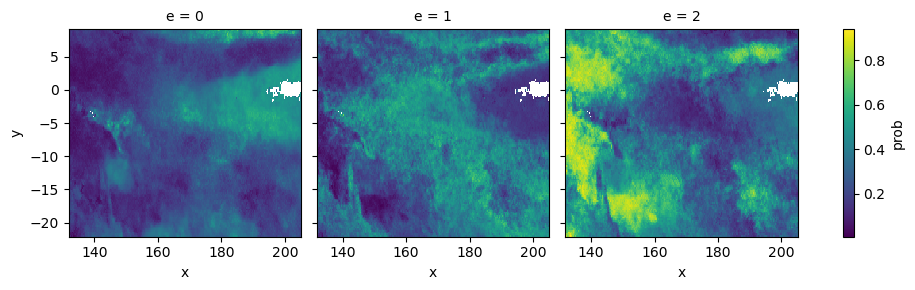

In [4]:
gefs_wk1cons = xr.open_dataset(os.path.join(gefs_procdir, 'gefs_week_1_cons.nc'))
gefs_wk1cons = gefs_wk1cons.rename({'lon':'x', 'lat':'y'})
gefs_wk1cons = gefs_wk1cons.sel(x=slice(0,359.999), y = slice(-50,50))
gefs_wk1cons.prob.plot(col = 'e')
gefs_wk1cons

In [5]:
import numpy as np
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

def collapse_to_max_probability_with_category(data):
    """
    Collapse the data along the 'e' dimension to retain the maximum probability for each grid cell
    and the corresponding category index.
    
    Parameters:
        data: xarray.DataArray
            The input data with shape (y, x, e) representing probabilities for multiple categories.
    
    Returns:
        max_prob: xarray.DataArray
            DataArray with maximum probabilities collapsed along the 'e' dimension.
        category_index: xarray.DataArray
            DataArray with the indices (or categories) corresponding to the max probabilities.
    """
     # Identify NaN mask
    nan_mask = data.isnull().all(dim='e')
    filled_data = data.where(~nan_mask, -1)
    # Collapse along the 'e' dimension to get the max probability for each grid cell
    max_prob = filled_data.max(dim="e")
    
    # Get the index of the category corresponding to the max probability
    category_index = filled_data.argmax(dim="e")
    
    return max_prob, category_index

def convert_to_mercator(ds):
    """
    Convert the xarray dataset to Mercator projection (EPSG:3857).

    Parameters:
        ds: xarray.DataArray
            The dataset to reproject.

    Returns:
        xarray.DataArray
            Reprojected dataset.
    """
    # Ensure CRS is set to EPSG:4326
    ds = ds.rio.write_crs("EPSG:4326", inplace=True)
    
    # Cast to float32 to avoid issues with int64 type during reprojection
    ds = ds.astype(np.float32)
    return ds.rio.reproject("EPSG:3857")  # Reproject to EPSG:3857 (Mercator)

def apply_colormap(da, colormap, norm, value_intervals):
    """
    Apply a custom colormap to the data array based on specified boundaries.
    
    Parameters:
        da: xarray.DataArray
            The data array to which the colormap will be applied.
        colormap: matplotlib.colors.Colormap
            The custom colormap to apply.
        norm: matplotlib.colors.BoundaryNorm
            The normalizer that defines the color intervals.
    
    Returns:
        xarray.DataArray
            DataArray with RGBA values.
    """
    # Clip the data to the specified range
    da_clipped = np.clip(da, value_intervals[0], value_intervals[-1])

    # Map the data values to the colormap using BoundaryNorm
    colormap_values = colormap(norm(da_clipped))

    # Scale to 0-255 for RGB and add an alpha channel
    da_rgb = (colormap_values[:, :, :3] * 255).astype(np.uint8)
    da_alpha = (~np.isnan(da_clipped)) * 255  # Transparency: 0 for NaN, 255 otherwise
    da_rgba = np.dstack((da_rgb, da_alpha.astype(np.uint8)))  # Combine RGB + Alpha

    # Convert to xarray for exporting with spatial coordinates
    da_rgba_xarray = xr.DataArray(
        da_rgba,
        dims=("y", "x", "band"),
        coords={"y": da.y, "x": da.x, "band": [1, 2, 3, 4]},
    )
    da_rgba_xarray = da_rgba_xarray.transpose("band", "y", "x").rio.write_crs(da.rio.crs)

    return da_rgba_xarray

def process_and_plot_gefs_probabilities(gefs_data, categories, colormaps, intervals, crs="EPSG:4326", time_index=0):
    """
    Full process to collapse GEFS probabilities, reproject to Mercator, and apply colormap.
    
    Parameters:
        gefs_data: xarray.Dataset
            The input dataset containing probabilities.
        categories: list of str
            List of category names (e.g., ["Below-Normal", "Near-Normal", "Above-Normal"]).
        colormaps: dict
            Dictionary mapping category names to their colormaps.
        intervals: dict
            Dictionary mapping category names to their interval boundaries.
        crs: str, optional
            Coordinate Reference System to assign to the dataset. Default is "EPSG:4326".
        time_index: int, optional
            The time index to select for processing. Default is 0.
    
    Returns:
        xarray.DataArray
            The processed RGBA map as an xarray DataArray.
    """
    # Extract probability data for the given time step
    data = gefs_data['prob'].isel(time=time_index) * 100  # Probabilities as percentages
    
    # Collapse the data to the max probability along the 'e' dimension and get the category index
    max_prob, category_index = collapse_to_max_probability_with_category(data)

    # Retain category_index but drop 'e' dimension before reprojecting
    max_prob_mercator = convert_to_mercator(max_prob)
    
    # Loop over the categories and apply the colormap and normalization for each one
    rgba_maps = {}
    for category in categories:
        # Get the colormap and intervals for this category
        category_colormap = colormaps[category]
        category_intervals = intervals[category]
        
        # Sample colors from the colormap using np.linspace to get evenly spaced values
        N = len(category_intervals) - 1  # Number of colors is one less than the number of intervals
        colormap_colors = category_colormap(np.linspace(0, 1, N))
        
        # Set up the norm using the correct intervals for this category
        norm = BoundaryNorm(category_intervals, len(colormap_colors))
        
        # Apply the colormap based on the category index (use max_prob_mercator to apply it on probabilities)
        rgba_map = apply_colormap(max_prob_mercator, category_colormap, norm, category_intervals)
        
        # Store the rgba_map for this category
        rgba_maps[category] = rgba_map

        # Plot the resulting RGBA map
        plt.figure(figsize=(12, 8))
        plt.imshow(rgba_map.transpose("y", "x", "band"), origin="upper", extent=[rgba_map.x.min(), rgba_map.x.max(), rgba_map.y.min(), rgba_map.y.max()])
        plt.title("Map of Tercile Categories by Highest Probability")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.show()

    return rgba_map

gefswk1_pcons_rgba = process_and_plot_gefs_probabilities(gefs_wk1cons, categories, colormaps, intervals, crs="EPSG:4326", time_index=0)

NameError: name 'colormaps' is not defined

In [6]:
colormaps = {"Below-Normal": bn_cmap, "Near-Normal": nn_cmap, "Above-Normal": an_cmap}
intervals = {"Below-Normal": bn_intervals, "Near-Normal": nn_intervals, "Above-Normal": an_intervals}
#convert lat/lon coords to mercator projection for tiles
def convert_to_mercator(ds, var):
    ds_mercator = ds.rio.reproject("EPSG:3857")
    return ds_mercator

# Apply the colormap and norm to the data
def apply_colormap(da, colormap, norm, value_intervals):
    """
    Apply a custom colormap to the data array based on specified boundaries.

    Parameters:
        da: xarray.DataArray
            The data array to which the colormap will be applied.
        colormap: matplotlib.colors.Colormap
            The custom colormap to apply.
        norm: matplotlib.colors.BoundaryNorm
            The normalizer that defines the color intervals.

    Returns:
        xarray.DataArray
            DataArray with RGBA values.
    """
    # Clip the data to the specified range (you could also use np.clip if needed)
    da_clipped = np.clip(da, value_intervals[0], value_intervals[-1])

    # Map the data values to the colormap using BoundaryNorm
    colormap_values = colormap(norm(da_clipped))

    # Scale to 0-255 for RGB and add an alpha channel
    da_rgb = (colormap_values[:, :, :3] * 255).astype(np.uint8)
    da_alpha = (~np.isnan(da_clipped)) * 255  # Transparency: 0 for NaN, 255 otherwise
    da_rgba = np.dstack((da_rgb, da_alpha.astype(np.uint8)))  # Combine RGB + Alpha

    # Convert to xarray for exporting with spatial coordinates
    da_rgba_xarray = xr.DataArray(
        da_rgba,
        dims=("y", "x", "band"),
        coords={"y": da.y, "x": da.x, "band": [1, 2, 3, 4]},
    )
    da_rgba_xarray = da_rgba_xarray.transpose("band", "y", "x").rio.write_crs(da.rio.crs)

    return da_rgba_xarray

def process_gefs_probabilities(gefs_data, categories, colormaps, intervals, crs="EPSG:4326", time_index=0):
    """
    Process GEFS probability data to create a combined RGBA map.

    Parameters:
        gefs_data: xarray.Dataset
            The input dataset containing probabilities.
        categories: list of str
            List of category names (e.g., ["Below-Normal", "Near-Normal", "Above-Normal"]).
        colormaps: dict
            Dictionary mapping category names to their colormaps.
        intervals: dict
            Dictionary mapping category names to their interval boundaries.
        crs: str, optional
            Coordinate Reference System to assign to the dataset. Default is "EPSG:4326".
        time_index: int, optional
            The time index to select for processing. Default is 0.

    Returns:
        xarray.DataArray
            Combined RGBA map as an xarray DataArray.
    """
    # Write CRS to the dataset
    gefs_data_crs = gefs_data.rio.write_crs(crs, inplace=False)

    # Select data for the given time step and scale probabilities
    data = gefs_data_crs['prob'].isel(time=time_index) * 100

    # Identify NaN mask
    nan_mask = data.isnull().all(dim='e')
    filled_data = data.where(~nan_mask, -1)

    # Compute the maximum category index
    max_cat_index = filled_data.argmax(dim="e")

    # Extract max probabilities for each category
    max_probs = {}
    for i, category in enumerate(categories):
        cat_prob = data.isel(e=i)  # Select probabilities for this category
        max_prob = cat_prob.where(max_cat_index == i)  # Retain only max category
        max_prob = max_prob.where(~nan_mask)  # Mask out all-NaN locations
        max_probs[category] = max_prob

    # Apply colormaps and combine RGBA maps
    rgba_maps = []
    for category in categories:
        prob = max_probs[category]
        cmap = colormaps[category]
        interval = intervals[category]
        norm = BoundaryNorm(interval, cmap.N, extend="both")

        # Apply the colormap
        rgba_map = apply_colormap(prob, cmap, norm, interval)
        rgba_maps.append(rgba_map)

    # Combine individual RGBA maps into a single map
    combined_rgba = np.zeros_like(rgba_maps[0].values)  # Initialize combined map
    for rgba_map in rgba_maps:
        mask = rgba_map[3, :, :] > 0  # Use alpha channel to identify valid data
        combined_rgba[:, mask] = rgba_map.values[:, mask]

    #Convert combined RGBA to xarray
    combined_rgba_xarray = xr.DataArray(
        combined_rgba,
        dims=("band", "y", "x"),
        coords={
            "band": [1, 2, 3, 4],
            "y": rgba_maps[0].y,
            "x": rgba_maps[0].x,
        },
    ).rio.write_crs(gefs_data_crs.rio.crs)

    return combined_rgba_xarray

def plot_rgba(data):
    # Plot the combined map
    plt.figure(figsize=(12, 8))
    plt.imshow(
        data.transpose("y", "x", "band"),  # Transpose to (y, x, rgba) for plotting
        origin="upper",
        extent=[data.x.min(), data.x.max(), data.y.min(), data.y.max()],
    )
    plt.title("Map of Tercile Categories by Highest Probability")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

gefswk1_pcons_rgba = process_gefs_probabilities(gefs_wk1cons, categories, colormaps, intervals,
                                               crs="EPSG:4326", time_index=0)
plot_rgba(gefswk1_pcons_rgba)
gefswk1pcons_prep = gefswk1_pcons_rgba.to_dataset(name = 'color')
gefswk1pcons_prep['x'] = (gefswk1pcons_prep.x + 180)%360 -180
gefswk1_pcons_mc = convert_to_mercator(gefswk1pcons_prep, 'color')
gefswk1_pcons_mc = gefswk1_pcons_mc.isel(y=slice(None,None,-1))
gefswk1_pcons_mc = gefswk1_pcons_mc.isel(x=slice(None,None,-1))
plot_rgba(gefswk1_pcons_mc['color'])
gefswk1_pcons_mc['color'].rio.to_raster(os.path.join(figure_dir, 'station_data', 'gefswk1pcons.tif'), dtype = 'uint8')

KeyError: 'Below Normal'

In [173]:
gefswk1_pcons_rgba

<xarray.DataArray (band: 4, y: 35, x: 397)>
array([[[232, 229, 234, ..., 234, 232, 234],
        [234, 232, 229, ..., 238, 236, 236],
        [236, 232, 232, ..., 238, 238, 238],
        ...,
        [234, 234, 238, ..., 234, 232, 232],
        [229, 229, 229, ..., 232, 229, 229],
        [232, 229, 229, ..., 234, 232, 229]],

       [[245, 244, 246, ..., 246, 245, 246],
        [246, 245, 244, ..., 248, 247, 247],
        [247, 245, 245, ..., 248, 248, 248],
        ...,
        [246, 246, 248, ..., 246, 245, 245],
        [244, 244, 244, ..., 245, 244, 244],
        [245, 244, 244, ..., 246, 245, 244]],

       [[243, 242, 244, ..., 244, 243, 244],
        [244, 243, 242, ..., 246, 245, 245],
        [245, 243, 243, ..., 246, 246, 246],
        ...,
        [244, 244, 246, ..., 244, 243, 243],
        [242, 242, 242, ..., 243, 242, 242],
        [243, 242, 242, ..., 244, 243, 242]],

       [[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]]], dtype=uint8)
Coordinates:
  * y            (y) float64 9.697e+05 8.689e+05 ... -2.357e+06 -2.458e+06
  * x            (x) float64 -1.999e+07 -1.989e+07 ... 1.984e+07 1.994e+07
  * band         (band) int64 1 2 3 4
    spatial_ref  int64 0

In [7]:
cons_stations = []
for station in stations:
    cons_station = gefs_wk1cons.sel(x=station['lon'], y = station['lat'], method = 'nearest')
    cons_station['station'] = station['name']
    cons_stations.append(cons_station)
cons_stations = xr.concat(cons_stations, dim = 'station')
cons_stations

<xarray.Dataset>
Dimensions:  (station: 75, time: 1, e: 3)
Coordinates:
    y        (station) float64 7.5 9.0 5.5 7.0 ... -17.25 -17.25 -18.25 -19.0
    x        (station) float64 151.8 138.2 153.8 158.2 ... 181.0 181.2 178.2
  * time     (time) datetime64[ns] 2024-12-03
  * e        (e) int64 0 1 2
  * station  (station) <U19 'Chuuk-Weno_FSM' ... 'Vunisea_Fiji'
Data variables:
    prob     (station, time, e) float64 0.1261 0.1821 0.6918 ... 0.3743 0.2842

In [15]:
categories = ['Below-Normal', 'Near-Normal', 'Above-Normal']
for s, station in enumerate(stations):
    bar_data = []

    # Prepare the data for each category (bn, nn, an)
    for c, cat in enumerate(categories):
        bar_data.append(cons_stations.isel(time=0,station=s,e=c).prob.values*100)

    colors = [
        get_color(bar_data[0], bn_intervals, bn_cmap),
        get_color(bar_data[1], nn_intervals, nn_cmap),
        get_color(bar_data[2], an_intervals, an_cmap),
    ]
    
    # Create the bar plot
    plt.bar(categories, bar_data, color=colors)
    # Add labels and title
    plt.ylabel("Probability (%)")
    plt.ylim(0,85)
    plt.title(station['name'] + ' GEFS Week 1 Consolidated Precip Probabilities')
    # Save the box plot as a PNG file with the station name
    plt.tight_layout()
    plt.savefig(os.path.join(figure_dir, 'station_data', f"{station['name']}_pconswk1bar.png"))  # Save as PNG file
    plt.close()  # Close the plot to avoid memory issues

In [9]:
# Helper function to map probability to color
def get_color(prob, intervals, cmap):
    norm_prob = (prob*100 - intervals[0]) / (intervals[-1] - intervals[0])  # Normalize to 0-1
    norm_prob = min(max(norm_prob, 0), 1)  # Clamp to [0, 1]
    color = cmap(norm_prob)
    # print(f"Probability: {prob}, Normalized: {norm_prob}, Color: {color}")  # Debugging
    return color

In [10]:
def prepare_max_category_dataarray(dataset, variable_name, categories):
    """
    Prepare a DataArray containing the probabilities of the maximum category for each grid cell.

    Parameters:
        dataset: xarray.Dataset
            The input dataset containing probabilities for each category along dimension `M`.
        variable_name: str
            The variable name to extract from the dataset (e.g., 'precip').
        categories: list
            A list of category names corresponding to the `M` dimension (e.g., ['bn', 'nn', 'an']).

    Returns:
        dict:
            A dictionary mapping category names to DataArrays of probabilities for the max category.
    """
    # Extract the data variable
    data = dataset[variable_name]
    
    nan_mask = data.isnull().all(dim="M") # Mask all-NaN slices
    filled_data = data.where(~nan_mask, -1) # Replace NaNs with a low value (e.g., -1) to safely compute argmax
    
    # Compute the maximum category index
    max_cat_index = filled_data.argmax(dim="M")

    # Dictionary to store DataArrays for each category
    max_probabilities = {}
    
    # Loop through categories to extract max probabilities
    for i, category in enumerate(categories):
        cat_prob = data.isel(M=i)  # Select probabilities for this category
        max_prob = cat_prob.where(max_cat_index == i)  # Retain only where it's the max category
        max_prob = max_prob.where(~nan_mask)  # Mask out all-NaN locations
        max_probabilities[category] = max_prob

    return max_probabilities

In [11]:
bn_intervals = [0,35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85]
bn_colors = [
    (254/255, 254/255, 254/255),#off white,
    (245/255, 230/255, 193/255),#light sand
    (233/255, 212/255, 159/255),#sand
    (222/255, 192/255, 123/255),#beige
    (206/255, 160/255,  83/255),#dark beige,
    (190/255, 128/255,  44/255),#light brown,
    (164/255, 104/255,  26/255),#lighmed brown
    (139/255,  81/255,  10/255),#med brown,
    (111/255,  63/255,   6/255),#dark med brown
    (100/255, 55/255, 6/255),#dark brown
    (82/255,  48/255,   6/255)#darkest brown
]
nn_intervals = [0,35,40,45,50,55]
nn_colors = [
    (254/255, 254/255, 254/255),#offwhite
    (238/255, 238/255, 233/255),#lightest gray
    (194/255, 194/255, 194/255),#light gray
    (176/255, 176/255, 176/255),#med gray
    (144/255, 144/255, 144/255)#dark gray
]

an_intervals = [0,35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85]
an_colors = [
    (254/255, 254/255, 254/255),#off white
    (198/255, 233/255, 227/255), # light mint
    (162/255, 218/255, 210/255),#mint green
    (144/255, 211/255, 201/255),#med turquoise
    (127/255, 203/255, 191/255),#dark turqouise
   (89/255, 176/255, 167/255), #light teal
     (52/255, 150/255, 142/255), #light med teal
    (26/255, 125/255, 117/255),#med teal
   (0/255, 101/255,  93/255), #med dark teal
    (0/255, 80/255 , 71/255), #darkets teal
    (3/255/255,  56/255,  47/255),#dark greem
]

categories = ["bn", "nn", "an"]
# Create colormaps
bn_cmap = LinearSegmentedColormap.from_list("browns", bn_colors)
nn_cmap = LinearSegmentedColormap.from_list("grays", nn_colors)
an_cmap = LinearSegmentedColormap.from_list("greens", an_colors)

# Prepare the data for each category
categories = ["bn", "nn", "an"]
max_probs = prepare_max_category_dataarray(gefs_wk1terc, 'precip', categories)
print(max_probs)
# Define colormaps and intervals for each category
colormaps = {"bn": bn_cmap, "nn": nn_cmap, "an": an_cmap}
intervals = {"bn": bn_intervals, "nn": nn_intervals, "an": an_intervals}

# Apply the colormap to each category and combine the results
rgba_maps = []
for category in categories:
    prob = max_probs[category]
    cmap = colormaps[category]
    interval = intervals[category]
    norm = BoundaryNorm(interval, cmap.N, extend="both")
    
    # Apply the colormap
    rgba_map = apply_colormap(prob, cmap, norm, interval)
    rgba_maps.append(rgba_map)

# Combine RGBA maps into a single map
combined_rgba = np.zeros_like(rgba_maps[0].values)  # Initialize combined map
for rgba_map in rgba_maps:
    mask = rgba_map[3, :, :] > 0  # Use alpha channel to identify valid data
    combined_rgba[:, mask] = rgba_map.values[:, mask]

# Plot the combined map
plt.figure(figsize=(12, 8))
plt.imshow(
    combined_rgba.transpose(1, 2, 0),  # Transpose to (y, x, rgba) for plotting
    origin="upper",
    extent=[gefs_wk1terc.x.min(), gefs_wk1terc.x.max(), gefs_wk1terc.y.min(), gefs_wk1terc.y.max()],
)
plt.title("Map of Tercile Categories by Highest Probability")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


NameError: name 'gefs_wk1terc' is not defined

In [120]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap



def compute_max_category(dataset, variable_name):
    """
    Computes the category with the highest probability along the 'M' dimension.
    Handles all-NaN slices gracefully by returning NaN for those locations.

    Parameters:
    - dataset (xarray.Dataset): The input dataset containing the data.
    - variable_name (str): The name of the variable (e.g., 'precip').

    Returns:
    - xarray.DataArray: An array with the indices of the maximum category,
                        with NaN for all-NaN slices.
    """
    # Extract the variable
    data = dataset[variable_name]
    
    # Mask all-NaN slices
    nan_mask = data.isnull().all(dim="M")
    
    # Replace NaNs with a low value (e.g., -1) to safely compute argmax
    filled_data = data.where(~nan_mask, -1)
    
    # Compute the index of the maximum category along 'M'
    max_category = filled_data.argmax(dim="M")
    
    # Mask the result for locations where all values were NaN
    max_category = max_category.where(~nan_mask, np.nan)
    
    return max_category

max_cat = compute_max_category(gefs_wk1terc, 'precip')
print(max_cat)

rgb_map = np.zeros((len(gefs_wk1terc.x), len(gefs_wk1terc.y), 3))
for i, cat in enumerate(categories):
    mask = gefs_wk1maxcat == i
    print(gefs_wk1terc)
    prob = gefs_wk1terc[cat].values
    print(mask)
    if cat == 1.0:
        cmap = bn_cmap
        intervals = bn_intervals
    elif cat == "nn":
        cmap = nn_cmap
        intervals = nn_intervals
    elif cat == "an":
        cmap = an_cmap
        intervals = an_intervals

    # Normalize probability into [0, 1] based on intervals
    normalized_prob = np.interp(prob, intervals, np.linspace(0, 1, len(intervals)))
    colors = cmap(normalized_prob)
    rgb_map[mask] = colors[mask]

# Plot the result
plt.figure(figsize=(10, 8))
plt.imshow(rgb_map, origin="upper", extent=[-5, 5, -5, 5])
plt.colorbar(label="Probability")
plt.title("Map of Tercile Categories by Highest Probability")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

<xarray.DataArray 'precip' (time: 1, y: 201, x: 721)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [ 1.,  1.,  1., ...,  1.,  1.,  1.],
        [ 0.,  1.,  1., ...,  0.,  0.,  0.],
        [nan,  1.,  1., ..., nan, nan, nan]]])
Coordinates:
  * y        (y) float64 -50.0 -49.5 -49.0 -48.5 -48.0 ... 48.5 49.0 49.5 50.0
  * x        (x) float64 0.0 0.5 1.0 1.5 2.0 ... 357.5 358.0 358.5 359.0 359.5
  * time     (time) datetime64[ns] 2024-11-26
<xarray.Dataset>
Dimensions:  (y: 201, x: 721, M: 3, time: 1)
Coordinates:
  * y        (y) float64 -50.0 -49.5 -49.0 -48.5 -48.0 ... 48.5 49.0 49.5 50.0
  * x        (x) float64 0.0 0.5 1.0 1.5 2.0 ... 357.5 358.0 358.5 359.0 359.5
  * M        (M) float64 1.0 2.0 3.0
  * time     (time) datetime64[ns] 2024-11-26
Data variables:
    precip   (M, time, y, x) float64 nan nan nan nan nan ... nan nan nan nan nan


KeyError: 'bn'

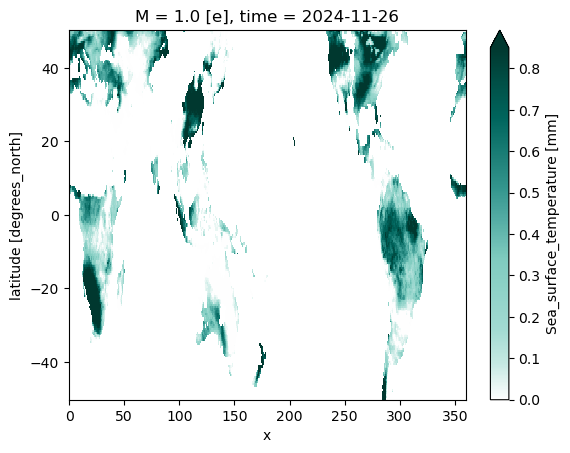

In [100]:
gefs_wk1terc.isel(M=0).precip.plot(cmap=custom_cmap, vmin=0, vmax=.85)

In [87]:
#convert lat/lon coords to mercator projection for tiles
def convert_to_mercator(ds, var):
    # ds = ds.where(~np.isnan(ds[var]), drop=True)
    ds_mercator = ds.rio.reproject("EPSG:3857")
    # ds_clip = ds_mercator.where(ds_mercator.notnull(), drop=True)
    return ds_mercator
#convert the data array to RGB values for image export using defined colorschemes


In [47]:
gefs_wk1raw

<xarray.Dataset>
Dimensions:  (y: 201, x: 721, time: 1)
Coordinates:
  * y        (y) float32 -50.0 -49.5 -49.0 -48.5 -48.0 ... 48.5 49.0 49.5 50.0
  * x        (x) float32 180.0 180.5 181.0 181.5 ... 178.5 179.0 179.5 180.0
  * time     (time) datetime64[ns] 2024-11-26
Data variables:
    precip   (time, y, x) float64 ...

In [56]:
mintotal = 0
maxtotal = 3500
gefs_wk1raw_crs = gefs_wk1raw.rio.write_crs('EPSG:4326', inplace = True)
gefs_wk1raw_clipped = gefs_wk1raw.sel(x=slice(0,359.5), y = slice(-50,50))
gefs_wk1raw_mc = convert_to_mercator(gefs_wk1raw_clipped, 'precip')
print(gefs_wk1raw_mc)
gefs_wk1rawnorm = np.clip(gefs_wk1raw_mc.precip, mintotal, maxtotal)

<xarray.Dataset>
Dimensions:      (x: 2311, y: 748, time: 1)
Coordinates:
  * x            (x) float64 -2.003e+07 -2.001e+07 ... 2.001e+07 2.003e+07
  * y            (y) float64 6.481e+06 6.464e+06 ... -6.455e+06 -6.472e+06
  * time         (time) datetime64[ns] 2024-11-26
    spatial_ref  int64 0
Data variables:
    precip       (time, y, x) float64 2.395 2.395 2.395 ... 4.111 4.111 4.111


In [71]:
from matplotlib.colors import BoundaryNorm, ListedColormap
total_intervals = [0, 2, 5, 10, 25, 50, 75, 100,
                    150, 200, 300, 500, 750, 1000,
                    1500, 2500, 3500]
total_cmap = ListedColormap(total_colors)
total_norm = BoundaryNorm(boundaries=total_intervals, ncolors=len(total_colors))
gefswk1tp_rgb = apply_colormap(gefs_wk1rawnorm.isel(time=0), total_cmap, total_norm, total_intervals)
gefswk1tp_rgb.rio.to_raster(os.path.join(figure_dir, 'gefswk1totalp.png'), dtype="uint8")

In [15]:
figure_dir = '/cpc/int_desk/pac_isl/stations/images'
gefs_dir = '/cpc/africawrf/ebekele/cca/xcast/subseason/prep_data/data' #this has the masked versions need to find unmasked
# nmme_dir = '/cpc/fews/production/NMME/inputs/filtered/netcdf/ncout'
# gefs_dir = '/cpc/fews/production/GEFS/output/bin'
# cdas_dir = '/cpc/data/cdas/rot_daily/pgb.2024*.grb2'

In [16]:
# gefs_daily = xr.open_mfdataset('/cpc/africawrf/ebekele/projects/PREPARE_pacific/notebooks/unmasked/*.nc')

In [24]:
gefs_try = xr.open_dataset(os.path.join(gefs_dir, 'gefs_week1_fcst.nc'))

In [25]:
# gefs_try = xr.open_dataset(os.path.join(gefs_dir, 'gefs_week1_raw_20241121.nc'))

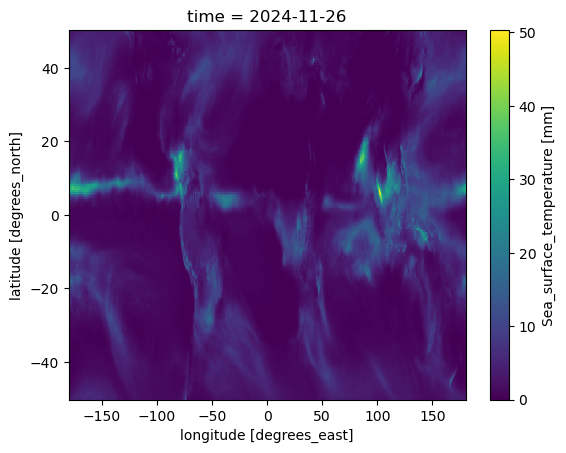

In [26]:
gefs_try.precip.plot()

In [85]:
nmme_fcst = xr.open_dataset(os.path.join(nmme_dir, 'nmme_prate_ensmean_fcst.nc'), engine = 'netcdf4', decode_times=False)
nmme_hcst =  xr.open_dataset(os.path.join(nmme_dir, 'nmme_prate_ensmean_hcst.nc'), engine = 'netcdf4', decode_times=False)
start_date = datetime(1991,1,1)

In [86]:
# Function to convert months to dates
def convert_months_to_dates(months, start_date):
    return [start_date + relativedelta(months=+m) for m in months]

def convert_mms_to_mmmonth(ds):
    fcst_month = np.array(dates_of_interest[0])
    fcst_month = fcst_month.astype('datetime64[M]').astype(int) % 12 + 1
    if fcst_month in [1,3,5,7,8,10,12]:
        days_in_month = 31
    elif fcst_month in [4,6,9,11]:
        days_in_month = 30
    elif fcst_month in [2]:
        days_in_month = 28
    ds_month = ds*60*60*24*days_in_month #update to mm/month
    return(ds_month)

In [92]:
print(len(nmme_hcst.time.values))

30


In [93]:
start_date = datetime(1991,1,1)
dates_of_interest = convert_months_to_dates(range(0,31), start_date)
print(dates_of_interest)
nmme_dates = []
for d, date in enumerate(dates_of_interest):
    nmme_date = nmme_hcst.isel(time = d)
    nmme_date = nmme_date.expand_dims({'time': [dates_of_interest[d]]})
    nmme_dates.append(nmme_date)
    
nmme_dates = xr.concat(nmme_dates, dim = 'time')
print(nmme_dates)


#update mm/s to mm/month
# raw_season_month = convert_mms_to_mmmonth(raw_season_times)

[datetime.datetime(1991, 1, 1, 0, 0), datetime.datetime(1991, 2, 1, 0, 0), datetime.datetime(1991, 3, 1, 0, 0), datetime.datetime(1991, 4, 1, 0, 0), datetime.datetime(1991, 5, 1, 0, 0), datetime.datetime(1991, 6, 1, 0, 0), datetime.datetime(1991, 7, 1, 0, 0), datetime.datetime(1991, 8, 1, 0, 0), datetime.datetime(1991, 9, 1, 0, 0), datetime.datetime(1991, 10, 1, 0, 0), datetime.datetime(1991, 11, 1, 0, 0), datetime.datetime(1991, 12, 1, 0, 0), datetime.datetime(1992, 1, 1, 0, 0), datetime.datetime(1992, 2, 1, 0, 0), datetime.datetime(1992, 3, 1, 0, 0), datetime.datetime(1992, 4, 1, 0, 0), datetime.datetime(1992, 5, 1, 0, 0), datetime.datetime(1992, 6, 1, 0, 0), datetime.datetime(1992, 7, 1, 0, 0), datetime.datetime(1992, 8, 1, 0, 0), datetime.datetime(1992, 9, 1, 0, 0), datetime.datetime(1992, 10, 1, 0, 0), datetime.datetime(1992, 11, 1, 0, 0), datetime.datetime(1992, 12, 1, 0, 0), datetime.datetime(1993, 1, 1, 0, 0), datetime.datetime(1993, 2, 1, 0, 0), datetime.datetime(1993, 3, 1, 0

IndexError: index 30 is out of bounds for axis 0 with size 30

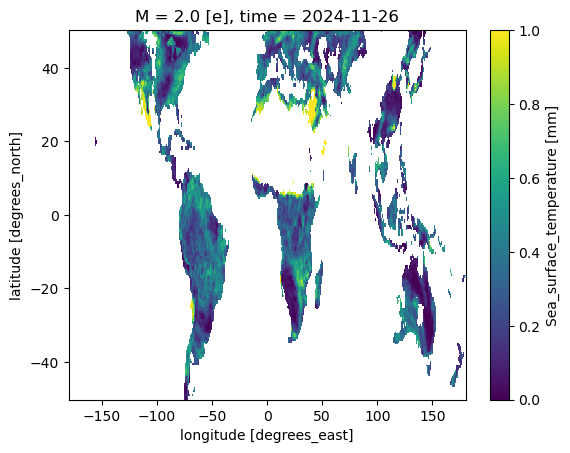

In [29]:
gefswk1 = xr.open_dataset(os.path.join(gefs_dir, 'gefs_week1_tercile.nc'))
gefswk1.precip.isel(M=1).plot()

In [28]:
gefswk1_stations = []
for s in stations:
    gefswk1_stations.append(gefswk1.sel(lat = s['lat'], lon = s['lon'], method = 'nearest').expand_dims({'station':[s['name']]}))
gefswk1_stations = xr.concat(gefswk1_stations, dim = 'station')

NameError: name 'gefswk1' is not defined

In [35]:
gefswk1_stations.isel(station=2)

<xarray.Dataset>
Dimensions:  (M: 3, time: 1)
Coordinates:
    station  <U11 'Lukunor_FSM'
    lat      float64 5.5
    lon      float64 154.0
  * M        (M) float64 1.0 2.0 3.0
  * time     (time) datetime64[ns] 2024-11-21
Data variables:
    precip   (M, time) float64 nan nan nan